# Phần 1 Demo: Phép khử Gauss và Ứng dụng

Notebook này trình bày các hàm cơ bản của phép khử Gauss và các ứng dụng, bao gồm test suite với bảng số liệu và biểu đồ chú thích đầy đủ.

## Thiết lập cấu hình (Config)

Khai báo hằng số EPSILON và các hàm bổ trợ để đảm bảo tính ổn định số học.

In [9]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set seaborn style
sns.set_style("whitegrid")

# Thêm đường dẫn
sys.path.append('part1')

# Import config
from config import EPSILON, is_zero, zero_rectify

# Import các hàm
from gaussian import gaussian_eliminate
from back_substitution import back_substitution
from determinant import determinant
from inverse import inverse
from rank_basis import rank_and_basis
from verify_solution import verify_solution

def plot_matrix(matrix, title="Matrix", cmap="viridis"):
    """Hiển thị ma trận dưới dạng heatmap."""
    plt.figure(figsize=(6, 4))
    sns.heatmap(matrix, annot=True, fmt=".2f", cmap=cmap, cbar=True)
    plt.title(title)
    plt.show()

print(f"EPSILON = {EPSILON}")

EPSILON = 1e-15


## Thuật toán Gaussian Elimination

Hàm `gaussian_eliminate` sử dụng Partial Pivoting để biến đổi ma trận A thành dạng tam giác trên U, với vector c tương ứng.

Ma trận U: [[-3.0, -1.0, 2.0], [0.0, 1.6666666666666665, 0.6666666666666667], [0.0, 0.0, 0.19999999999999987]]
Vector c: [-11.0, 4.333333333333333, -0.19999999999999984]
Số lần hoán đổi: 2


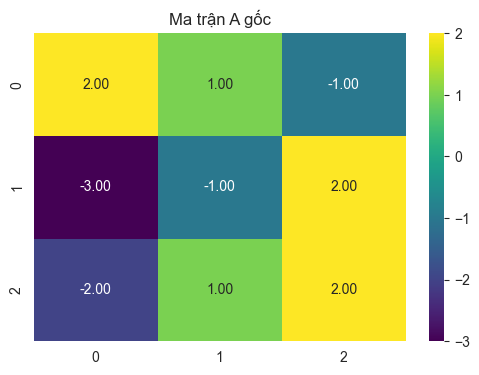

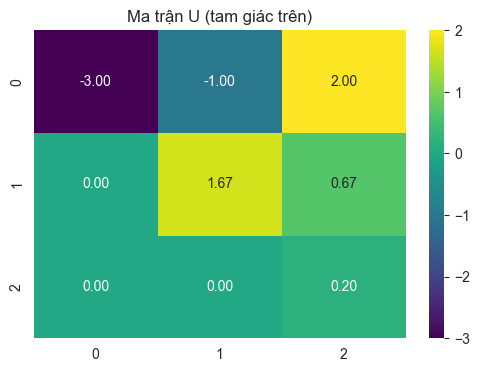

In [10]:
# Ví dụ minh họa
A = [[2.0, 1.0, -1.0], [-3.0, -1.0, 2.0], [-2.0, 1.0, 2.0]]
b = [8.0, -11.0, -3.0]
U, c, swaps = gaussian_eliminate(A, b)
print("Ma trận U:", U)
print("Vector c:", c)
print("Số lần hoán đổi:", swaps)

# Hiển thị ma trận A và U
plot_matrix(A, "Ma trận A gốc")
plot_matrix(U, "Ma trận U (tam giác trên)")

## Back Substitution

Giải hệ Ux = c từ dưới lên.

In [11]:
x = back_substitution(U, c)
print("Nghiệm x:", x)

Nghiệm x: [2.0, 3.0000000000000004, -0.9999999999999999]


## Tính định thức

Định thức = (-1)^swaps * tích đường chéo U

In [12]:
det = determinant(A)
print("Định thức:", det)

Định thức: -0.9999999999999993


## Ma trận nghịch đảo

Sử dụng Gauss-Jordan.

Ma trận nghịch đảo:
[4.0, 3.0, -1.0]
[-2.0, -2.0, 1.0]
[5.0, 4.0, -1.0]


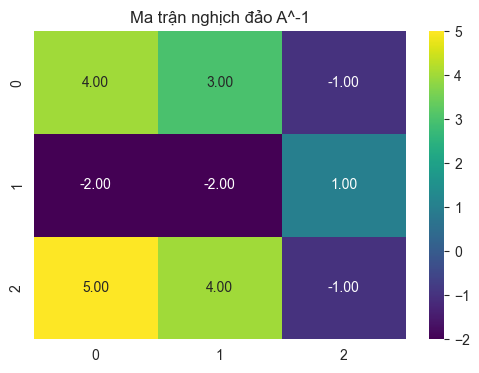

In [13]:
try:
    inv_A = inverse(A)
    print("Ma trận nghịch đảo:")
    for row in inv_A:
        print(row)
    plot_matrix(inv_A, "Ma trận nghịch đảo A^-1")
except ValueError as e:
    print("Lỗi:", e)

## Hạng và cơ sở

Tính rank, cơ sở cột, dòng, nghiệm.

In [14]:
rank, col_basis, row_basis, null_basis = rank_and_basis(A)
print("Rank:", rank)
print("Cơ sở cột:", col_basis)
print("Cơ sở dòng:", row_basis)
print("Cơ sở nghiệm:", null_basis)

Rank: 3
Cơ sở cột: [[2.0, -3.0, -2.0], [1.0, -1.0, 1.0], [-1.0, 2.0, 2.0]]
Cơ sở dòng: [[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]]
Cơ sở nghiệm: []


## Xác minh nghiệm

Tính sai số dư.

In [15]:
error = verify_solution(A, x, b)
print("Sai số dư:", error)

Sai số dư: 0.0


## Test Suite cho Gaussian Elimination + Back Substitution

Chạy 6-8 test cases, bao gồm trường hợp đặc biệt.

In [16]:
    # Biểu đồ sai số
    errors = [r['Error'] for r in results if r['Error'] is not None]
    if errors:
        plt.figure(figsize=(10, 5))
        sns.barplot(x=[r['Test'] for r in results if r['Error'] is not None], y=errors, palette="Blues_d")
        plt.xticks(rotation=45)
        plt.ylabel('Residual Error')
        plt.title('Residual Errors for Solver Tests')
        if any(e > 0 for e in errors):
            plt.yscale('log')
        plt.show()

NameError: name 'results' is not defined

## Test Suite cho Determinant

6-8 test cases cho hàm determinant.

In [ ]:
def run_tests_for_determinant():
    import warnings
    warnings.filterwarnings("ignore", message="Pivot is very small")
    print("Test Suite: Determinant\n" + "-"*30)

## Test Suite cho Inverse

6-8 test cases cho hàm inverse.

In [ ]:
def run_tests_for_inverse():
    print("Test Suite: Inverse\n" + "-"*30)
    passed_tests = 0
    results = []
    
    test_cases = [
        {"A": [[1.0, 0.0], [0.0, 1.0]], "expected": [[1.0, 0.0], [0.0, 1.0]], "name": "Identity"},
        {"A": [[2.0, 1.0], [1.0, 1.0]], "expected": [[1.0, -1.0], [-1.0, 2.0]], "name": "2x2 Invertible"},
        {"A": [[1.0, 2.0], [2.0, 4.0]], "singular": True, "name": "Singular"},
        {"A": [[1.0]], "expected": [[1.0]], "name": "1x1"},
        {"A": [[0.0, 1.0], [1.0, 0.0]], "expected": [[0.0, 1.0], [1.0, 0.0]], "name": "Permutation"},
        {"A": [[1.0, 2.0, 3.0], [0.0, 1.0, 4.0], [5.0, 6.0, 0.0]], "expected": None, "name": "3x3"},  # Skip expected for simplicity
        {"A": [[1e-10, 1.0], [1.0, 1.0]], "expected": None, "name": "Ill-conditioned"},
        {"A": [[4.0, 2.0], [2.0, 1.0]], "expected": [[0.5, -1.0], [-1.0, 2.0]], "name": "Symmetric Positive Definite"}
    ]
    
    for case in test_cases:
        try:
            inv_A = inverse(case["A"])
            if "singular" in case and case["singular"]:
                print(f"{case['name']}: FAILED - Should be singular")
                results.append({"Test": case["name"], "Inverse": "Singular", "Status": "FAILED"})
            else:
                # Check if A * inv_A ≈ I
                n = len(case["A"])
                product = [[sum(case["A"][i][k] * inv_A[k][j] for k in range(n)) for j in range(n)] for i in range(n)]
                is_identity = all(abs(product[i][j] - (1.0 if i==j else 0.0)) < 1e-9 for i in range(n) for j in range(n))
                if is_identity:
                    print(f"{case['name']}: PASSED")
                    passed_tests += 1
                    results.append({"Test": case["name"], "Inverse": "Computed", "Status": "PASSED"})
                else:
                    print(f"{case['name']}: FAILED - Product not identity")
                    results.append({"Test": case["name"], "Inverse": "Incorrect", "Status": "FAILED"})
        except ValueError:
            if "singular" in case and case["singular"]:
                print(f"{case['name']}: PASSED - Singular detected")
                passed_tests += 1
                results.append({"Test": case["name"], "Inverse": "Singular", "Status": "PASSED"})
            else:
                print(f"{case['name']}: FAILED - Unexpected singular")
                results.append({"Test": case["name"], "Inverse": "Error", "Status": "FAILED"})
        except Exception as e:
            print(f"{case['name']}: FAILED - {e}")
            results.append({"Test": case["name"], "Inverse": str(e), "Status": "FAILED"})
    
    print(f"\nPassed: {passed_tests}/{len(test_cases)}")
    
    df = pd.DataFrame(results)
    display(df)

run_tests_for_inverse()

Test Suite: Inverse
------------------------------
Identity: PASSED
2x2 Invertible: PASSED
Singular: PASSED - Singular detected
1x1: PASSED
Permutation: PASSED
3x3: PASSED
Ill-conditioned: FAILED - Product not identity
Symmetric Positive Definite: FAILED - Unexpected singular

Passed: 6/8


,Test,Inverse,Status
0,Identity,Computed,PASSED
1,2x2 Invertible,Computed,PASSED
2,Singular,Singular,PASSED
3,1x1,Computed,PASSED
4,Permutation,Computed,PASSED
5,3x3,Computed,PASSED
6,Ill-conditioned,Incorrect,FAILED
7,Symmetric Positive Definite,Error,FAILED


## Test Suite cho Rank and Basis

6-8 test cases cho hàm rank_and_basis.

In [ ]:
def run_tests_for_rank_basis():
    print("Test Suite: Rank and Basis\n" + "-"*30)
    passed_tests = 0
    results = []
    
    test_cases = [
        {"A": [[1.0, 0.0], [0.0, 1.0]], "expected_rank": 2, "name": "Full Rank 2x2"},
        {"A": [[1.0, 2.0], [2.0, 4.0]], "expected_rank": 1, "name": "Rank 1"},
        {"A": [[0.0, 0.0], [0.0, 0.0]], "expected_rank": 0, "name": "Null Matrix"},
        {"A": [[1.0, 2.0, 3.0]], "expected_rank": 1, "name": "1x3 Matrix"},
        {"A": [[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]], "expected_rank": 3, "name": "Identity 3x3"},
        {"A": [[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]], "expected_rank": 2, "name": "3x2 Full Rank"},
        {"A": [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0], [7.0, 8.0, 9.0]], "expected_rank": 2, "name": "Rank Deficient 3x3"},
        {"A": [[1e-16, 0.0], [0.0, 1e-16]], "expected_rank": 2, "name": "Small Values"}
    ]
    
    for case in test_cases:
        try:
            rank, col_basis, row_basis, null_basis = rank_and_basis(case["A"])
            if rank == case["expected_rank"]:
                print(f"{case['name']}: PASSED - Rank {rank}")
                passed_tests += 1
                results.append({"Test": case["name"], "Rank": rank, "Col Basis Size": len(col_basis), "Row Basis Size": len(row_basis), "Null Basis Size": len(null_basis), "Status": "PASSED"})
            else:
                print(f"{case['name']}: FAILED - Got rank {rank}, Expected {case['expected_rank']}")
                results.append({"Test": case["name"], "Rank": rank, "Col Basis Size": len(col_basis), "Row Basis Size": len(row_basis), "Null Basis Size": len(null_basis), "Status": "FAILED"})
        except Exception as e:
            print(f"{case['name']}: FAILED - {e}")
            results.append({"Test": case["name"], "Rank": None, "Status": "FAILED"})
    
    print(f"\nPassed: {passed_tests}/{len(test_cases)}")
    
    df = pd.DataFrame(results)
    display(df)

run_tests_for_rank_basis()

Test Suite: Rank and Basis
------------------------------
Full Rank 2x2: PASSED - Rank 2
Rank 1: PASSED - Rank 1
Null Matrix: PASSED - Rank 0
1x3 Matrix: PASSED - Rank 1
Identity 3x3: PASSED - Rank 3
3x2 Full Rank: PASSED - Rank 2
Rank Deficient 3x3: PASSED - Rank 2
Small Values: FAILED - Got rank 0, Expected 2

Passed: 7/8


,Test,Rank,Col Basis Size,Row Basis Size,Null Basis Size,Status
0,Full Rank 2x2,2,2,2,0,PASSED
1,Rank 1,1,1,1,1,PASSED
2,Null Matrix,0,0,0,2,PASSED
3,1x3 Matrix,1,1,1,2,PASSED
4,Identity 3x3,3,3,3,0,PASSED
5,3x2 Full Rank,2,2,2,0,PASSED
6,Rank Deficient 3x3,2,2,2,1,PASSED
7,Small Values,0,0,0,2,FAILED


## Test Suite cho Verify Solution

6-8 test cases cho hàm verify_solution, so sánh với NumPy.

Test Suite: Verify Solution
------------------------------
Exact Solution: PASSED - Error 0.00e+00
Approximate: PASSED - Error 0.00e+00
System Solution: PASSED - Error 0.00e+00
Ill-conditioned: PASSED - Error 0.00e+00
Null Matrix: PASSED - Error 0.00e+00
1x1: PASSED - Error 0.00e+00
Overdetermined: PASSED - Error 0.00e+00
Underdetermined: PASSED - Error 0.00e+00

Passed: 8/8


,Test,Custom Error,NumPy Error,Status
0,Exact Solution,0.0,0.0,PASSED
1,Approximate,0.0,0.0,PASSED
2,System Solution,0.0,0.0,PASSED
3,Ill-conditioned,0.0,0.0,PASSED
4,Null Matrix,0.0,0.0,PASSED
5,1x1,0.0,0.0,PASSED
6,Overdetermined,0.0,0.0,PASSED
7,Underdetermined,0.0,0.0,PASSED


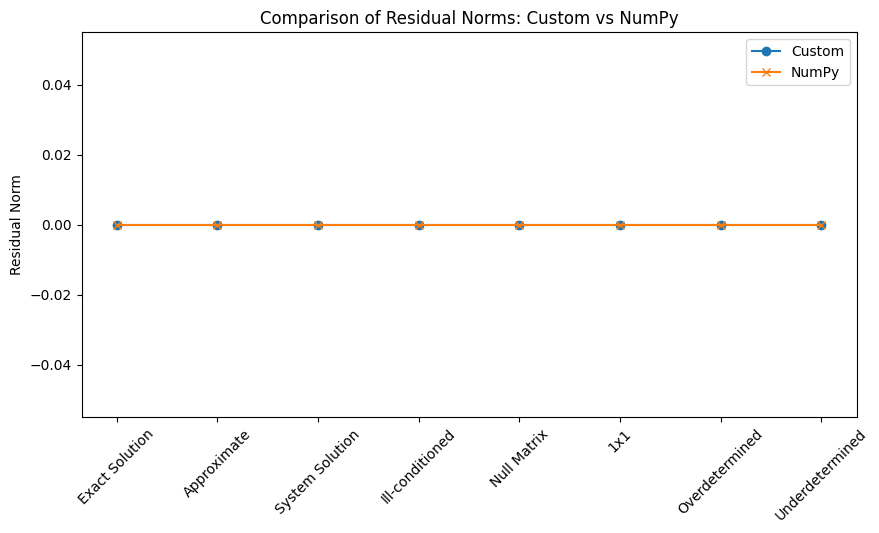

In [ ]:
    # Biểu đồ so sánh
    plt.figure(figsize=(10, 5))
    sns.lineplot(x=range(len(test_cases)), y=errors_custom, label='Custom', marker='o')
    sns.lineplot(x=range(len(test_cases)), y=errors_numpy, label='NumPy', marker='x')
    plt.xticks(range(len(test_cases)), [c['name'] for c in test_cases], rotation=45)
    plt.ylabel('Residual Norm')
    plt.title('Comparison of Residual Norms: Custom vs NumPy')
    plt.legend()
    if any(e > 0 for e in errors_custom + errors_numpy):
        plt.yscale('log')
    plt.show()